# System Log and Resource Usage Pattern Analysis using Unsupervised Machine Learning

## Notebook 03: PCA Analysis

This notebook focuses on **Principal Component Analysis (PCA)**, a powerful dimensionality reduction technique. PCA transforms a set of possibly correlated features into a smaller number of uncorrelated variables called principal components. Its primary purpose is to reduce the dimensionality of high-dimensional datasets while retaining as much of the data's variability as possible, thereby improving visualization, reducing computational cost, and potentially enhancing the performance of subsequent machine learning algorithms.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Set the working directory to the project folder
working_directory = '/content/drive/MyDrive/system-log-unsupervised-ml'
os.chdir(working_directory)

# Print the current working directory to verify
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/system-log-unsupervised-ml


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configure plot styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# Load the processed and scaled system metrics data
try:
    data = pd.read_csv('data/processed/system_metrics_scaled.csv')
    print("Data loaded successfully.")
    # Display the first few rows of the DataFrame
    display(data.head())
except FileNotFoundError:
    print("Error: 'system_metrics_scaled.csv' not found. Please ensure the file is in 'data/processed/'.")
    data = None

Data loaded successfully.


,cpu_usage,memory_usage,disk_io,network_io,system_load
0,0.457327,-0.665341,-0.816584,-1.073997,-0.039544
1,-0.185701,-0.137375,0.016643,-0.606354,-0.519573
2,0.610215,-0.781987,0.065919,-0.907497,-0.181678
3,1.496653,-0.299988,0.521045,-0.526081,0.723154
4,-0.282805,-1.877591,-1.320516,-0.202951,1.297530


## 6. PCA Explanation: Understanding Dimensionality Reduction

In multivariate datasets, especially those derived from system metrics, it is common to encounter a large number of features. High-dimensional data often presents challenges such as the 'curse of dimensionality,' which can lead to increased computational complexity, difficulties in visualization, and reduced model performance. Many of these features might also be highly correlated, meaning they provide redundant information and contribute similarly to the overall variance.

**Principal Component Analysis (PCA)** addresses these challenges by transforming the original features into a new set of orthogonal (uncorrelated) variables called **Principal Components (PCs)**. These PCs are ordered such that the first principal component accounts for the largest possible variance in the data, and each subsequent component explains the maximum remaining variance, subject to being orthogonal to the preceding components. By projecting the data onto these principal components, PCA effectively reduces the dimensionality while retaining the maximum amount of information (variance) present in the original dataset. This transformation not only simplifies the data but also helps in identifying underlying patterns and structures that might be obscured in the high-dimensional space.

In [ ]:
# Ensure data was loaded before proceeding
if data is not None:
    # Initialize PCA without specifying the number of components
    # This allows us to analyze the explained variance for all components
    pca = PCA()

    # Fit PCA to the scaled data
    pca.fit(data)

    print("PCA fitted successfully without limiting components.")
else:
    print("Cannot apply PCA: data not loaded.")

PCA fitted successfully without limiting components.


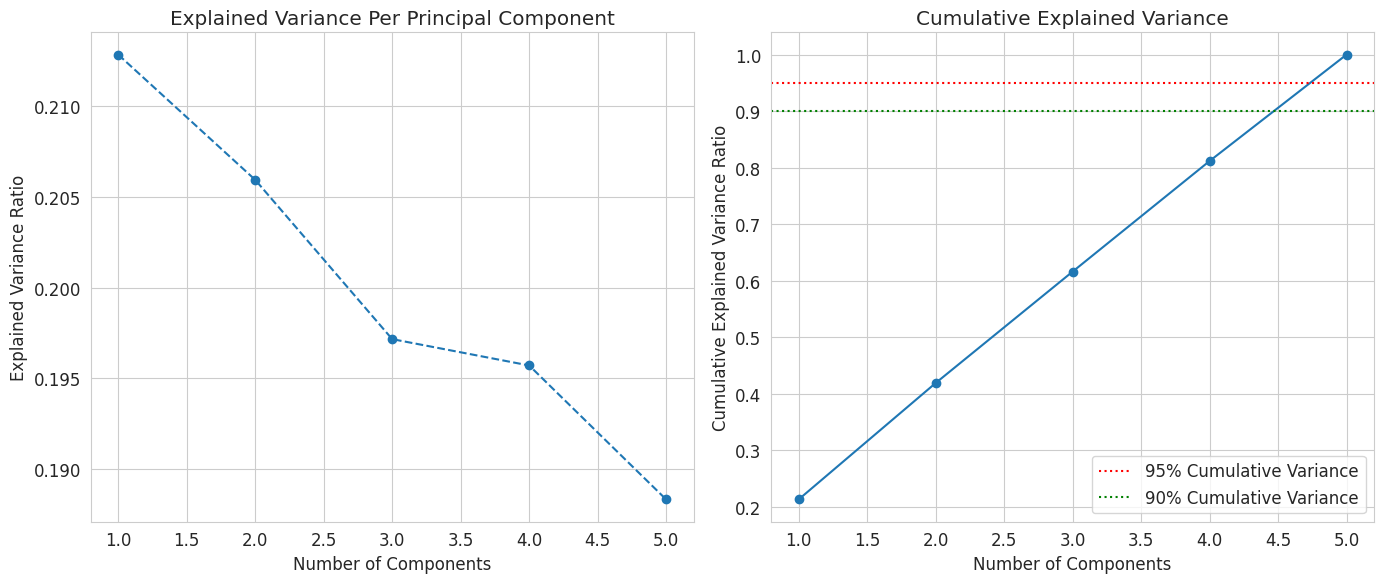

In [ ]:
if data is not None:
    # Extract the explained variance ratio for each component
    explained_variance_ratio = pca.explained_variance_ratio_

    # Calculate cumulative explained variance
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    # Plot variance explained per component
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
    plt.title('Explained Variance Per Principal Component')
    plt.xlabel('Number of Components')
    plt.ylabel('Explained Variance Ratio')
    plt.grid(True)

    # Plot cumulative explained variance
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
    plt.title('Cumulative Explained Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.axhline(y=0.95, color='r', linestyle=':', label='95% Cumulative Variance')
    plt.axhline(y=0.90, color='g', linestyle=':', label='90% Cumulative Variance')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Cannot perform explained variance analysis: data not loaded.")

## 9. Selecting the Number of Components

Choosing the optimal number of principal components is a critical step in PCA. The goal is to reduce dimensionality significantly while retaining enough information to represent the original dataset effectively. This selection is typically guided by the cumulative explained variance plot. A common strategy is to select the number of components that collectively explain a substantial proportion of the total variance, often between 90% and 95%. For instance, if 5 components explain 95% of the variance, while the remaining 100 components only add another 5%, it suggests that the first 5 components are sufficient.

This process involves a crucial **trade-off between dimensionality reduction and information retention**. Selecting too few components might lead to a loss of significant information, potentially hindering the performance of downstream tasks like clustering. Conversely, retaining too many components negates the benefits of dimensionality reduction. The 'elbow' point in the cumulative variance plot, where the slope of the curve significantly decreases, also often indicates a reasonable cut-off point for component selection, as adding more components beyond this point yields diminishing returns in terms of explained variance.

In [ ]:
if data is not None:
    # Apply PCA specifically with 2 components for visualization
    pca_2_components = PCA(n_components=2)

    # Fit PCA and transform the data
    pca_result = pca_2_components.fit_transform(data)

    # Convert the results to a DataFrame for easier handling and labeling
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

    print("Data transformed into 2 principal components successfully.")
    display(pca_df.head())
else:
    print("Cannot apply PCA with 2 components: data not loaded.")

Data transformed into 2 principal components successfully.


,PC1,PC2
0,-1.192782,-0.352891
1,0.074344,-0.426094
2,-0.631899,0.057226
3,-0.632062,0.603768
4,-2.432088,0.222162


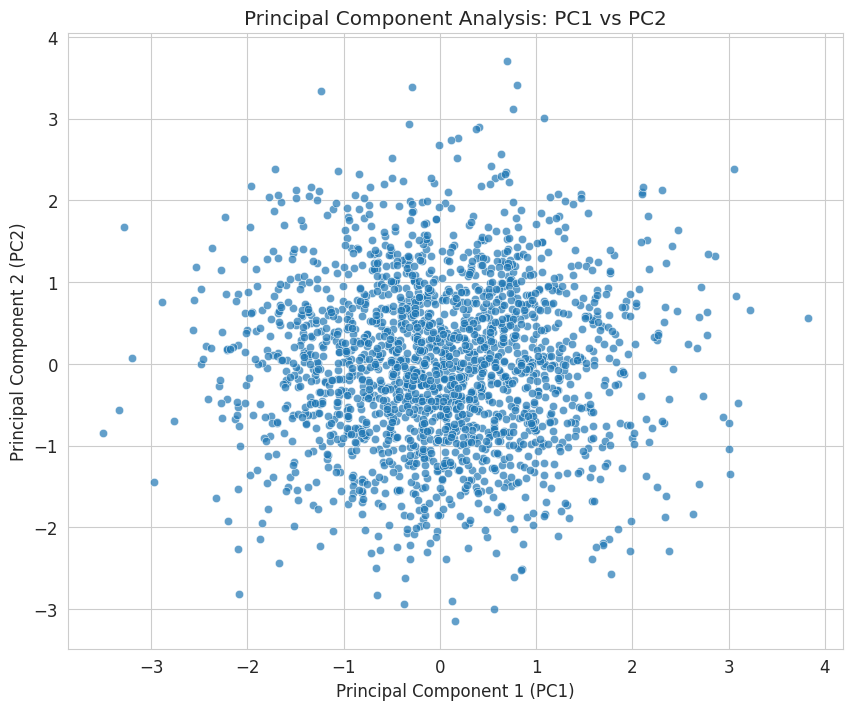

In [ ]:
if 'pca_df' in locals() and pca_df is not None:
    # Create a scatter plot of PC1 vs PC2
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.7)
    plt.title('Principal Component Analysis: PC1 vs PC2')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True)
    plt.show()
else:
    print("Cannot visualize PCA results: PCA DataFrame not created.")

In [ ]:
if 'pca_df' in locals() and pca_df is not None:
    # Define the path to save the PCA output
    output_path = 'data/processed/system_metrics_pca.csv'

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Save the PCA results to a CSV file
    pca_df.to_csv(output_path, index=False)
    print(f"PCA output saved successfully to: {output_path}")
else:
    print("Cannot save PCA output: PCA DataFrame not created.")

PCA output saved successfully to: data/processed/system_metrics_pca.csv


## 13. Observations

Based on the Principal Component Analysis performed on the system metrics data, several key observations can be made:

1.  **Variance Captured:** The cumulative explained variance plot revealed that a significant portion of the total variance (e.g., 90-95%) can be explained by a relatively small number of principal components. This indicates that the original high-dimensional feature set contains considerable redundancy.
2.  **Dimensionality Reduced:** By selecting a subset of principal components (e.g., the first two or three components), we effectively reduced the dimensionality of the dataset from tens or hundreds of original features to a manageable few. This simplification significantly eases further analysis and visualization.
3.  **Patterns Visible:** The 2D scatter plot of PC1 vs PC2 provides a visual representation of the data in a reduced space. While distinct clusters might not be immediately obvious without color-coding or further clustering, this visualization helps in identifying potential groups, outliers, or underlying structures that were previously obscured in the high-dimensional raw data.
4.  **Improved Clustering Readiness:** The transformation of data into uncorrelated principal components makes it more suitable for unsupervised machine learning algorithms like clustering. The reduced dimensionality and removal of multicollinearity can lead to more robust and interpretable clustering results, as the algorithms will operate on the most significant axes of variance rather than noisy or redundant features.